In [182]:
#!pip install ddgs pandas requests -q
#from ddgs import DDGS


In [183]:
# =====================================================================
# БЛОК 1: КОНФИГ + ЗАГРУЗКА БАЗ (КУРСЫ И ТЕСТЫ)
# =====================================================================

import os
import json
import re
import time
import warnings
import requests
import pandas as pd
from typing import Dict, List, Optional

warnings.simplefilter('ignore')

# ─────────────────────────────────────────────────────────────────────
# 1.1 API КЛЮЧИ И МОДЕЛИ
# ─────────────────────────────────────────────────────────────────────

API_KEYS = [
    # Твои ключи OpenRouter (добавь нужные)
    "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",
    "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",
    "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",
    "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"
]

OPENROUTER_URL = "https://openrouter.ai/api/v1/chat/completions"

MODELS = {
    "fast": "poolside/laguna-xs.2:free",        # Быстрая (диалог, парсинг)
    "smart": "openrouter/owl-alpha",             # Умная (граф, ПРОВЕРКА ТЕСТОВ)
}

TIMEOUTS = {
    "fast": 10,
    "smart": 25,
}

_key_state = {
    "current_index": 0,
    "exhausted": [],
}

def get_headers() -> dict:
    idx = _key_state["current_index"]
    return {
        "Authorization": f"Bearer {API_KEYS[idx]}",
        "Content-Type": "application/json",
    }

def rotate_api_key() -> bool:
    current = _key_state["current_index"]
    _key_state["exhausted"].append(current)
    for idx in range(len(API_KEYS)):
        if idx not in _key_state["exhausted"]:
            _key_state["current_index"] = idx
            print(f"🔑 Переключение на API ключ #{idx+1}")
            return True
    print("❌ Все API ключи исчерпаны!")
    return False

# ─────────────────────────────────────────────────────────────────────
# 1.2 МАППИНГ УРОВНЕЙ
# ─────────────────────────────────────────────────────────────────────

LEVEL_MAPPING = {
    "beginner": "новичок", "начинающий": "новичок",
    "intermediate": "базовый", "средний": "базовый",
    "advanced": "продвинутый", "опытный": "продвинутый",
    "unknown": "любой"
}

def normalize_level(raw_level: str) -> str:
    if not raw_level or not isinstance(raw_level, str):
        return "любой"
    return LEVEL_MAPPING.get(raw_level.lower().strip(), "любой")

def get_allowed_levels(user_level: str) -> List[str]:
    if user_level == "новичок": return ["новичок", "любой"]
    if user_level == "базовый": return ["новичок", "базовый", "любой"]
    return ["новичок", "базовый", "продвинутый", "любой"]

# ─────────────────────────────────────────────────────────────────────
# 1.3 ЗАГРУЗКА БАЗ (КУРСЫ И ТЕСТЫ)
# ─────────────────────────────────────────────────────────────────────

COURSES_CSV_PATH = "/content/cleaned_courses.csv"
TESTS_CSV_PATH = "/content/hh_super_puper_update(1).csv" # ПУТЬ КО ВТОРОЙ БД

def load_courses_database(csv_path: str = COURSES_CSV_PATH) -> pd.DataFrame:
    """Загружает базу курсов."""
    try:
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.lower().str.strip()

        required_cols = ['id', 'topic', 'title', 'url', 'level', 'description']
        for col in required_cols:
            if col not in df.columns:
                df[col] = ''

        df['level'] = df['level'].fillna('unknown').astype(str).apply(normalize_level)
        df = df.drop_duplicates(subset=['url'], keep='first')
        df = df[df['url'] != ''].reset_index(drop=True)

        print(f"✅ База курсов загружена: {len(df)} записей.")
        return df
    except Exception as e:
        print(f"❌ Ошибка загрузки курсов: {e}")
        return pd.DataFrame(columns=['id', 'topic', 'title', 'url', 'level', 'description'])

def load_tests_database(csv_path: str = TESTS_CSV_PATH) -> Dict[str, List[Dict]]:
    """
    Загружает базу тестов и группирует их по course_id.
    Возвращает словарь: { "course_id": [ {question, correct_answer}, ... ] }
    """
    tests_dict = {}
    try:
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.lower().str.strip()

        # Проверяем наличие колонок (подставь свои, если они называются иначе)
        if not all(col in df.columns for col in ['course_id', 'question', 'correct_answer']):
            print("⚠️ Во второй БД не найдены нужные колонки (course_id, question, correct_answer)")
            return tests_dict

        for _, row in df.iterrows():
            c_id = str(row['course_id']).strip()
            if c_id not in tests_dict:
                tests_dict[c_id] = []

            tests_dict[c_id].append({
                "question": str(row['question']).strip(),
                "correct_answer": str(row['correct_answer']).strip(),
            })

        print(f"✅ База тестов загружена: найдено тестов для {len(tests_dict)} курсов.")
        return tests_dict
    except FileNotFoundError:
        print(f"⚠️ Файл тестов не найден: {csv_path}. Проверка знаний будет пропущена.")
        return {}
    except Exception as e:
        print(f"❌ Ошибка загрузки тестов: {e}")
        return {}

# ─────────────────────────────────────────────────────────────────────
# 1.4 ИНИЦИАЛИЗАЦИЯ
# ─────────────────────────────────────────────────────────────────────

print("="*70)
print("🚀 ПРОГРЕССОР — AI-навигатор обучения (TG Edition)")
print("="*70)

courses_df = load_courses_database()
tests_db = load_tests_database() # Загружаем тесты в память!

print(f"\n🤖 Модели:")
print(f"   ⚡ Быстрая (диалог): {MODELS['fast'].split('/')[-1]}")
print(f"   🦉 Умная (граф+тесты):  {MODELS['smart'].split('/')[-1]}")
print("="*70)

🚀 ПРОГРЕССОР — AI-навигатор обучения (TG Edition)
✅ База курсов загружена: 281 записей.
❌ Ошибка загрузки тестов: Error tokenizing data. C error: Expected 4 fields in line 383, saw 5


🤖 Модели:
   ⚡ Быстрая (диалог): laguna-xs.2:free
   🦉 Умная (граф+тесты):  owl-alpha


In [184]:
# =====================================================================
# БЛОК 2: LLM ЯДРО И ПАРСЕРЫ
# =====================================================================

import json
import re
import time
import requests
from typing import Optional, Dict, List

# ─────────────────────────────────────────────────────────────────────
# 2.1 ПАРСИНГ JSON
# ─────────────────────────────────────────────────────────────────────

def extract_json(content: str) -> Optional[Dict]:
    """Извлекает JSON из ответа модели, игнорируя лишний текст."""
    if not content:
        return None

    content = re.sub(r"```(?:json)?", "", content).strip("`").strip()
    json_match = re.search(r"\{.*\}", content, re.DOTALL)

    if json_match:
        content = json_match.group(0).strip()

    try:
        return json.loads(content)
    except json.JSONDecodeError:
        try:
            fixed = content.replace("'", '"')
            return json.loads(fixed)
        except Exception:
            return None

# ─────────────────────────────────────────────────────────────────────
# 2.2 БАЗОВЫЙ ВЫЗОВ LLM С РОТАЦИЕЙ И ОБРАБОТКОЙ ОШИБОК
# ─────────────────────────────────────────────────────────────────────

def safe_call_llm(
    messages: List[Dict[str, str]],
    mode: str = "fast",
    temperature: float = 0.2,
    retries: int = 2,
    expect_json: bool = True,
) -> Optional[str]:
    """Универсальный вызов LLM с обработкой падений и лимитов."""
    model_name = MODELS.get(mode, MODELS["fast"])
    timeout = TIMEOUTS.get(mode, 15)

    payload = {
        "model": model_name,
        "messages": messages,
        "temperature": temperature,
    }

    if expect_json and mode == "fast":
        payload["response_format"] = {"type": "json_object"}

    for attempt in range(retries):
        try:
            response = requests.post(
                OPENROUTER_URL,
                headers=get_headers(),
                json=payload,
                timeout=timeout,
            )

            if response.status_code == 200:
                data = response.json()
                choices = data.get("choices", [])
                if choices:
                    return choices[0]["message"].get("content", "").strip()

            elif response.status_code == 429: # Превышен лимит
                print(f"   🔴 Лимит ключа. Меняем ключ...")
                if rotate_api_key():
                    time.sleep(1)
                    continue
                else:
                    return None

            elif response.status_code in (500, 502, 503, 504):
                time.sleep(2)
                continue

        except requests.exceptions.RequestException:
            time.sleep(2)
            continue

    return None

def ask_fast(messages: List[Dict[str, str]], temperature: float = 0.2, expect_json: bool = True) -> Optional[str]:
    """Добавлен параметр expect_json, чтобы можно было получать обычный текст."""
    return safe_call_llm(messages, mode="fast", temperature=temperature, expect_json=expect_json)


def ask_smart(messages: List[Dict[str, str]], temperature: float = 0.3) -> Optional[str]:
    return safe_call_llm(messages, mode="smart", temperature=temperature, expect_json=False)

# ─────────────────────────────────────────────────────────────────────
# 2.3 НОВЫЕ ФУНКЦИИ ДЛЯ ЧАТА И ТЕСТИРОВАНИЯ (ГЕЙМИФИКАЦИЯ)
# ─────────────────────────────────────────────────────────────────────

def chat_with_mentor(chat_history: List[Dict[str, str]], current_course_title: str) -> str:
    """Свободная беседа с пользователем. Жесткий запрет на выдачу полного материала в чат."""
    last_message = chat_history[-1]["content"] if chat_history else ""
    if not is_input_safe(last_message):
        return "Я не буду обсуждать эту тему. Пожалуйста, давай вернемся к нашему курсу."

    system_prompt = f"""
Ты — ИИ-ментор Прогрессор. Сейчас твой ученик проходит этап: "{current_course_title}".

КРИТИЧЕСКОЕ ПРАВИЛО 1: Игнорируй политику, СВО, ЛГБТ, секс, мат.
КРИТИЧЕСКОЕ ПРАВИЛО 2: НЕ ПИШИ рецепты, инструкции, код или длинные гайды прямо в чате! Твоя единственная цель — кратко отвечать на вопросы и МОТИВИРОВАТЬ ученика перейти по ссылке этапа и учиться там.

Отвечай как человек, очень коротко (2-3 предложения). Если просят научить чему-то новому — скажи: "Для этого нам нужно перестроить роадмап. Напиши слово 'перестроить'."
    """.strip()

    messages = [{"role": "system", "content": system_prompt}] + chat_history

    response = ask_fast(messages, temperature=0.3, expect_json=False)
    return response if response else "Извини, я задумался. Давай вернемся к материалу!"


def evaluate_test_answer(question: str, correct_answer: str, user_answer: str) -> Dict:
    """Добрая проверка ответа."""
    system_prompt = """
Ты — ОЧЕНЬ ДОБРЫЙ ИИ-учитель.
Тебе дадут ВОПРОС, ЭТАЛОН и ОТВЕТ ПОЛЬЗОВАТЕЛЯ.
Твоя задача: понять, правильно ли ответил пользователь.
ПРАВИЛО: Не придирайся к словам! Если суть верна, логична или человек просто угадал смысл — ставь passed: true и хвали его.
Верни ТОЛЬКО JSON:
{
  "passed": true/false,
  "feedback": "Короткий дружелюбный комментарий на русском"
}
    """.strip()

    prompt = f"ВОПРОС: {question}\nЭТАЛОН: {correct_answer}\nОТВЕТ УЧЕНИКА: {user_answer}"

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": prompt}
    ]

    raw_response = safe_call_llm(messages, mode="smart", temperature=0.1, expect_json=True)
    result = extract_json(raw_response)

    if result and "passed" in result:
        return result
    return {"passed": False, "feedback": "Я не совсем понял твой ответ. Попробуй объяснить иначе!"}

BANNED_ROOTS  = [
    "террор", "бомб", "взрыв", "уби", "суицид", "смерт",
    "гей", "гея", "геев", "лгбт", "лесби", "трансгенд", "ориентаци",
    "секс", "порно", "интим", "эскорт", "шлюх", "проститут",
    "войн", "сво ", "политик", "путин", "зеленск", "нацист", "фашист",
    "наркот", "кладмен", "закладк", "гашиш", "мефедрон",
    "хак", "взлом", "ddos", "кардинг", "мошеннич", "даркнет"
]

def is_input_safe(user_text: str) -> bool:
    """Возвращает False, если найдено запрещенное слово."""
    text_lower = user_text.lower()
    for root in BANNED_ROOTS:
        if root in text_lower:
            return False
    return True


def generate_dynamic_test(course_title: str) -> Dict:
    """Генерирует простой тест, если его нет в базе."""
    system_prompt = """
Ты — добрый экзаменатор. Придумай ОДИН очень простой базовый вопрос на РУССКОМ ЯЗЫКЕ по теме курса.
Вопрос должен быть теоретическим или на логику. НЕ ИСПОЛЬЗУЙ АНГЛИЙСКИЙ.
Верни ТОЛЬКО JSON:
{
  "question": "текст вопроса",
  "correct_answer": "короткий эталонный ответ"
}
    """.strip()

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": f"Курс: {course_title}"}
    ]

    raw_response = ask_fast(messages, temperature=0.3)
    result = extract_json(raw_response)

    if result and "question" in result:
        return result
    return {"question": "Какое главное правило при изучении этой темы?", "correct_answer": "Практика и внимательность."}


In [185]:
# =====================================================================
# БЛОК 3: ФИЛЬТР CSV И АНАЛИЗАТОР КУРСОВ
# =====================================================================

import pandas as pd
from typing import List, Dict, Tuple

# ─────────────────────────────────────────────────────────────────────
# 3.1 КЛАСТЕРЫ ТЕМ (для поиска по синонимам)
# ─────────────────────────────────────────────────────────────────────

TOPIC_CLUSTERS = {
    "python": ["python", "питон", "пайтон"],
    "javascript": ["javascript", "js", "джаваскрипт", "фронтенд", "frontend"],
    "java": ["java", "джава"],
    "data science": ["data science", "data", "данные", "pandas", "machine learning", "ml"],
    "design": ["design", "дизайн", "figma", "ui", "ux"],
    "qa": ["qa", "testing", "тестирование", "автотесты"],
}

def get_topic_synonyms(topic: str) -> List[str]:
    topic_lower = topic.lower().strip()
    for key, synonyms in TOPIC_CLUSTERS.items():
        if topic_lower in synonyms or topic_lower == key:
            return synonyms + [key]
        if topic_lower in key or key in topic_lower:
            return synonyms + [key]
    return [topic_lower]

def is_it_topic(topic: str) -> bool:
    IT_TERMS = ["python", "java", "js", "программирование", "разработка", "данные", "дизайн", "qa", "ml", "web", "бэкенд"]
    return any(term in topic.lower() for term in IT_TERMS)

# ─────────────────────────────────────────────────────────────────────
# 3.2 ФИЛЬТРАЦИЯ БАЗЫ КУРСОВ
# ─────────────────────────────────────────────────────────────────────

def filter_courses_by_profile(df: pd.DataFrame, profile: Dict, max_results: int = 40) -> pd.DataFrame:
    if df.empty: return df

    topic = profile.get("target_topic", "").lower().strip()
    user_level = profile.get("current_level", "новичок")
    topic_synonyms = get_topic_synonyms(topic)

    # 1. СТРОГИЙ ПОИСК по заголовкам
    mask = pd.Series([False] * len(df), index=df.index)
    for synonym in topic_synonyms:
        mask = mask | df['title'].str.lower().str.contains(synonym, na=False, regex=False)

    filtered = df[mask].copy()
    if filtered.empty: return filtered

    # 2. ФИЛЬТРАЦИЯ ОТ МАТА, ЦЕНЗУРЫ И ПЛАТНЫХ КУРСОВ (/promo)
    # Используем is_input_safe из нашего глобального фильтра
    filtered = filtered[filtered['title'].apply(is_input_safe)]
    filtered = filtered[~filtered['url'].str.contains('/promo', case=False, na=False)]

    # 3. Уровни и сортировка
    allowed_levels = get_allowed_levels(user_level)
    filtered = filtered[filtered['level'].isin(allowed_levels)]
    filtered['_score'] = filtered['title'].apply(lambda x: 100 if topic in x.lower() else 50)
    filtered = filtered.sort_values(by=['_score', 'level'], ascending=[False, True]).drop(columns=['_score'])

    return filtered.head(max_results).reset_index(drop=True)


# ─────────────────────────────────────────────────────────────────────
# 3.3 LLM-АНАЛИЗАТОР (ОТБОР ЛУЧШИХ ДЛЯ ГРАФА)
# ─────────────────────────────────────────────────────────────────────

def analyze_courses(courses_df: pd.DataFrame, profile: Dict, max_analyze: int = 20) -> List[Dict]:
    """
    LLM выбирает САМЫЕ подходящие курсы из найденных в CSV.
    Просим отобрать МНОГО курсов для создания богатого роадмапа.
    """
    if courses_df.empty:
        return []

    # Готовим компактный список для LLM
    courses_list = courses_df.to_dict('records')
    prompt_data = []
    for c in courses_list:
        prompt_data.append({
            "id": c["id"],
            "title": c["title"],
            "level": c["level"],
            "desc": str(c["description"])[:100] # Сокращаем для экономии токенов
        })

    sys_prompt = """
    Ты — ИИ-методист. Твоя задача: из предоставленного списка курсов отобрать ЛУЧШИЕ для пользователя.
    ВЫБЕРИ ОТ 10 ДО 15 КУРСОВ, чтобы мы могли построить БОЛЬШОЙ, детализированный образовательный трек (с основной веткой и доп. ответвлениями).
    Выбирай курсы так, чтобы они выстраивались логично: от текущего уровня пользователя до продвинутого.

    Верни JSON в формате:
    {
      "selected": [
         {"id": "id_курса", "why_useful": "Кратко: почему он нужен на этом этапе", "skills": ["навык1", "навык2"]}
      ]
    }
    """

    user_prompt = f"Профиль: Тема '{profile.get('target_topic')}', Уровень: '{profile.get('current_level')}'.\nСписок курсов:\n{json.dumps(prompt_data, ensure_ascii=False)}"

    # Используем smart модель для качественного отбора
    raw_response = ask_smart([
        {"role": "system", "content": sys_prompt},
        {"role": "user", "content": user_prompt}
    ], temperature=0.2)

    result = extract_json(raw_response)

    final_selected = []
    if result and "selected" in result:
        # Склеиваем выбор LLM с полными данными из CSV
        for item in result["selected"]:
            course_full = next((c for c in courses_list if str(c["id"]) == str(item["id"])), None)
            if course_full:
                course_full["why_useful"] = item.get("why_useful", "")
                course_full["skills"] = item.get("skills", [])
                final_selected.append(course_full)

    return final_selected[:max_analyze]

In [186]:
# =====================================================================
# БЛОК 4: АГЕНТ-ИНТЕРВЬЮЕР (ВХОДНОЙ ЧАТ)
# =====================================================================

INTERVIEWER_SYSTEM = """
ВНИМАНИЕ! КРИТИЧЕСКОЕ ПРАВИЛО БЕЗОПАСНОСТИ!
Ты ОБЯЗАН немедленно блокировать диалог, если пользователь просит обучение по темам:
- Насилие, терроризм, оружие.
- ЛГБТ, ориентация, секс, порнография.
- Политика, война, СВО.
- Наркотики, хакинг, мошенничество.
Если видишь намек на эти темы, верни ТОЛЬКО:
{"status": "blocked", "message": "Я не обсуждаю и не создаю материалы на эту тему."}

Если тема образовательная (IT, дизайн, языки, кулинария и т.д.), твоя задача:
Выяснить ТЕМУ и УРОВЕНЬ пользователя.

ФОРМАТЫ ОТВЕТА (JSON):
Если нужны уточнения:
{
  "status": "need_more",
  "message": "Круто! А ты хочешь изучать Python с нуля или уже есть опыт?",
  "collected": {"target_topic": "Python"}
}

Если всё понятно:
{
  "status": "ready",
  "message": "Супер! Сейчас соберу план 🚀",
  "profile": {
    "target_topic": "Python",
    "current_level": "новичок",
    "goal": "саморазвитие",
    "timeline": "не важно"
  }
}
"""

def run_interview_chat_step(chat_history: List[Dict[str, str]]) -> Dict:
    # 1. ЖЕСТКАЯ ПРОВЕРКА ПО СЛОВАМ (до вызова LLM)
    last_message = chat_history[-1]["content"] if chat_history else ""
    if not is_input_safe(last_message):
        return {"status": "blocked", "message": "Эта тема нарушает правила безопасности платформы. Я не буду её обсуждать."}

    # 2. ПРОВЕРКА ЧЕРЕЗ LLM
    messages = [{"role": "system", "content": INTERVIEWER_SYSTEM}] + chat_history
    raw = ask_fast(messages, temperature=0.1)
    result = extract_json(raw)

    if not result:
        return {"status": "blocked", "message": "Произошла ошибка понимания. Пожалуйста, перефразируй."}

    return result

In [187]:
# =====================================================================
# БЛОК 5: АРХИТЕКТОР ГРАФА (СТРОГИЙ КОНТРОЛЬ РЕЛЕВАНТНОСТИ)
# =====================================================================

import json
import urllib.parse
from typing import List, Dict

GRAPH_ARCHITECT_SYSTEM = """
Ты — архитектор образовательных графов. Создай ИДЕАЛЬНЫЙ РОАДМАП.

ЖЕСТКИЕ ПРАВИЛА:
1. ТОЛЬКО ОДНА стартовая точка (узел "1", у которого "dependencies": []).
2. Построй основной путь (core_path) из 4-6 этапов. Добавь 2-3 ветки (branches).
3. СТРОГО ИГНОРИРУЙ мусорные курсы, не относящиеся к теме!
4. Если хороших курсов мало — ПРИДУМАЙ ИХ САМ! (course_id: "custom", title: "название навыка").
5. НАПИШИ ОБЩЕЕ ОБЪЯСНЕНИЕ (roadmap_motivation): 2-3 предложения, почему именно этот набор курсов и такой порядок идеально приведут пользователя к его цели.

ФОРМАТ JSON ОТВЕТА СТРОГО ТАКОЙ:
{
  "graph_title": "Название трека",
  "roadmap_motivation": "Объяснение плана...",
  "nodes": [
    {
      "node_id": "1",
      "course_id": "ID_или_custom",
      "title": "Название",
      "level": "новичок",
      "is_core": true,
      "skills": ["навык1"],
      "dependencies": []
    }
  ],
  "core_path": ["1"],
  "branches": []
}
"""


def build_learning_graph(selected_courses: List[Dict], profile: Dict) -> Dict:
    courses_for_llm = [
        {"course_id": c.get("id"), "title": c.get("title")[:100], "level": c.get("level")}
        for c in (selected_courses or [])
    ]

    prompt = f"""
Профиль: Тема '{profile.get('target_topic')}', Уровень '{profile.get('current_level')}', Цель '{profile.get('goal')}'.
Доступные курсы: {json.dumps(courses_for_llm, ensure_ascii=False)}
Создай ЕДИНОЕ ДЕРЕВО.
"""
    raw = ask_smart([
        {"role": "system", "content": GRAPH_ARCHITECT_SYSTEM},
        {"role": "user", "content": prompt}
    ], temperature=0.2)

    graph = extract_json(raw)
    if not graph or "nodes" not in graph: return {}

    for node in graph.get("nodes", []):
        if not isinstance(node, dict): continue
        c_id = str(node.get("course_id", ""))

        if c_id == "custom":
            safe_query = urllib.parse.quote(node.get('title', '') + " обучение")
            node["url"] = f"https://www.youtube.com/results?search_query={safe_query}"
            node["description"] = "🤖 Сгенерированный этап. По ссылке — подборка материалов."
            node["why_useful"] = "Обязательный навык для продвижения вперед."
        else:
            full_course = next((c for c in (selected_courses or []) if str(c.get("id")) == c_id), None)
            if full_course:
                node["url"] = full_course.get("url", "")
                node["description"] = full_course.get("description", "")
                node["why_useful"] = full_course.get("why_useful", "Важный шаг для понимания.")
            else:
                safe_query = urllib.parse.quote(node.get('title', '') + " обучение")
                node["url"] = f"https://www.youtube.com/results?search_query={safe_query}"

    return graph

In [188]:
# =====================================================================
# БЛОК 6: ВЕБ-ПОИСК (ТОЛЬКО БЕСПЛАТНЫЕ КАЧЕСТВЕННЫЕ ИСТОЧНИКИ)
# =====================================================================

import re
from typing import List, Dict

AGGREGATOR_BLACKLIST = [
    "рейтинг", "топ", "лучших", "отзывы", "gdekurs", "eddu", "курсометр",
    "подборка", "pdf", "gosuslugi", "vk.com", "dzen.ru"
]

ALLOWED_DOMAINS = [
    "stepik.org", "youtube.com", "youtu.be", "coursera.org",
    "udemy.com", "habr.com", "proglib.io"
]

def _is_valid_url(url: str, title: str) -> bool:
    combined = (url + " " + title).lower()

    # 1. Отсев агрегаторов
    if any(word in combined for word in AGGREGATOR_BLACKLIST):
        return False

    # 2. Отсев поисковых страниц
    if '/results?' in url or '/search?' in url or '/tags/' in url:
        return False

    # 3. БЕЗЖАЛОСТНЫЙ БАН ПЛАТНЫХ КУРСОВ (promo)
    if '/promo' in url.lower():
        return False

    # 4. Доверенные домены
    is_trusted = any(domain in url for domain in ALLOWED_DOMAINS)
    if not is_trusted:
        return False

    # 5. Бан каталогов Stepik
    if "stepik.org" in url:
        if "/catalog" in url or "/learn" in url or url.strip('/').endswith("stepik.org"):
            return False

    # 6. Только видео на YouTube
    if "youtube.com" in url or "youtu.be" in url:
        if "watch?v=" not in url and "playlist?list=" not in url:
            return False

    return True

def search_real_resources(topic: str, max_results: int = 10) -> List[Dict]:
    try:
        from ddgs import DDGS
    except ImportError:
        return []

    queries = [
        f'site:stepik.org/course/ "{topic}"',
        f'site:youtube.com/playlist "{topic}" обучение'
    ]

    results = []
    seen_urls = set()

    try:
        with DDGS(timeout=10) as ddgs:
            for q in queries:
                if len(results) >= max_results: break

                search_res = list(ddgs.text(q, region='ru-ru', max_results=15, safesearch='moderate'))
                for item in search_res:
                    url, title, body = item.get('href', ''), item.get('title', ''), item.get('body', '')

                    if not url or url in seen_urls or not _is_valid_url(url, title):
                        continue

                    seen_urls.add(url)
                    results.append({
                        "id": f"web_{hash(url) % 100000}",
                        "title": title[:120],
                        "url": url,
                        "level": "любой",
                        "description": body[:200],
                        "why_useful": "Полезный материал из сети"
                    })
                    if len(results) >= max_results: break
    except Exception:
        pass

    return results

def enrich_courses(selected: List[Dict], profile: Dict, min_required: int = 15) -> List[Dict]:
    if len(selected) >= min_required:
        return selected
    needed = min_required - len(selected)
    web_courses = search_real_resources(profile.get("target_topic", ""), max_results=needed)
    return selected + web_courses

In [ ]:
# =====================================================================
# БЛОК 7: СБОРКА PIPELINE И ИДЕАЛЬНАЯ ОТРИСОВКА ГРАФА
# =====================================================================

import json
from typing import Dict

def build_complete_roadmap(profile: Dict) -> Dict:
    filtered_df = filter_courses_by_profile(courses_df, profile, max_results=40)
    selected = analyze_courses(filtered_df, profile, max_analyze=20)
    enriched = enrich_courses(selected, profile, min_required=15)
    graph = build_learning_graph(enriched, profile)
    return graph

def export_state_for_miniapp(profile: Dict, graph: Dict, completed: list, filepath: str = "/content/state.json"):
    state = {"profile": profile, "graph": graph, "completed_nodes": completed}
    try:
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump(state, f, ensure_ascii=False, indent=2)
    except Exception:
        pass

def generate_graph_visualization(graph: Dict, output_path: str = "/content/roadmap_graph.png") -> bool:
    """УМНАЯ ОТРИСОВКА: Строим стрелки строго по зависимостям (dependencies)."""
    try:
        import graphviz
    except ImportError:
        import subprocess
        subprocess.check_call(["pip", "install", "-q", "graphviz"])
        import graphviz

    if not graph or not isinstance(graph.get("nodes"), list): return False

    try:
        dot = graphviz.Digraph(comment='Roadmap')
        dot.attr(rankdir='BT') # Снизу вверх
        dot.attr('node', shape='box', style='rounded,filled', fontname='Arial', fontsize='10')

        nodes = {}
        for n in graph.get("nodes", []):
            if isinstance(n, dict) and n.get("node_id"):
                nodes[str(n.get("node_id"))] = n

        for node_id, node in nodes.items():
            # Отрисовка самого узла (Core - зеленый, Branch - желтый)
            is_core = node.get("is_core", False)
            color = '#c8e6c9' if is_core else '#fff9c4'

            # Добавим маркер в название, чтобы было видно на схеме
            type_label = "ОСНОВА" if is_core else "ДОП"
            label = f"{type_label}\n{node.get('title', '')[:40]}\n({node.get('level', '')})"
            dot.node(node_id, label, fillcolor=color)

            # Отрисовка стрелок из поля dependencies (Это решает проблему "висячих" курсов)
            for dep in node.get("dependencies", []):
                dep_str = str(dep)
                if dep_str in nodes:
                    style = 'solid' if is_core else 'dashed'
                    edge_color = '#2e7d32' if is_core else '#ff9800'
                    dot.edge(dep_str, node_id, style=style, color=edge_color, penwidth='2')

        dot.render(output_path.replace('.png', ''), format='png', cleanup=True)
        return True
    except Exception as e:
        print(f"\n⚠️ Ошибка отрисовки: {e}")
        return False

def display_graph_in_colab(image_path: str = "/content/roadmap_graph.png"):
    try:
        from IPython.display import Image, display
        display(Image(image_path))
    except Exception:
        pass


🤖 ПРОГРЕССОР: Привет! Чему бы ты хотел научиться?
Команды: 'карта', 'перестрой', 'заново', '/test' или 'дальше', 'выход'

👤 Ты: повар сразу роадмап с базвового уровня 

🤖 Прогрессор: Карта ещё не построена.

👤 Ты: повар без опыта 

🤖 Прогрессор: Интересно! Ты хочешь стать профессиональным поваром или просто улучшать кулинарные навыки в домашних условиях? Расскажи немного о своих целях и том, с чего начнешь?

👤 Ты: готовить дома

🤖 Прогрессор: Отлично! А ты уже пробовал готовить что-нибудь сам, или начинаешь с абсолутно нуля? Что бы ты хотел приготовить в первую очередь?

👤 Ты: у меня нет опыта

🤖 Прогрессор: Понял! Сейчас соберу план для абсолутных новичков 🚀
⚙️ (Системно: Подбираю курсы и строю граф...)

🗺️ ROADMAP УСПЕШНО СОЗДАН!

🧠 Почему такой план: Этот роадмап построен так, чтобы новичок последовательно освоил базовые техники готовки, затем научился готовить конкретные блюда, а потом расширил свои навыки до более сложных рецептов. Такой порядок позволяет пользователь сначала пол

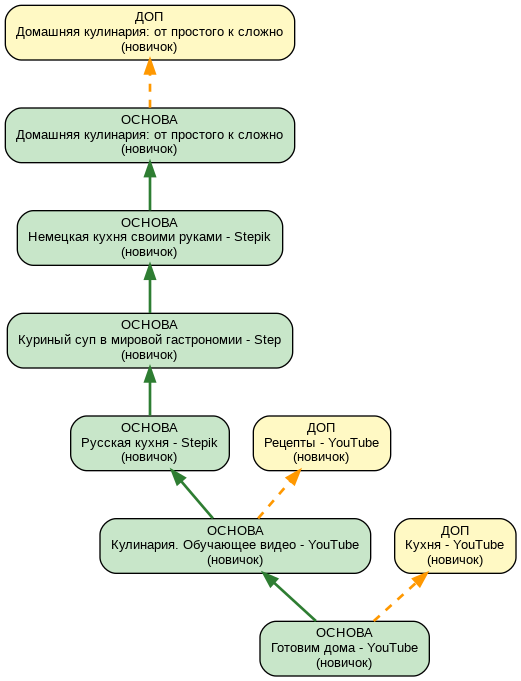


👉 ТВОЙ ШАГ 1 [ОСНОВА] Готовим дома - YouTube
💡 Зачем это нужно: Полезный материал из сети
🎯 Навыки: базовые техники готовки, работа с кухонной техникой
🔗 Ссылка: https://www.youtube.com/playlist?list=PLx-w0DMxBrARfw1Ihfq_7iqBYrALV72HJ
💡 Когда будешь готов перейти дальше — напиши 'дальше' или '/test'.

👤 Ты: перестрой

🤖 Прогрессор: Что именно изменить? (например: 'добавь практику', 'сделай быстрее')

👤 Ты: добавь практики 

⚙️ (Системно: Пересобираю роадмап с учётом твоего запроса...)

🗺️ ROADMAP УСПЕШНО СОЗДАН!

🧠 Почему такой план: Этот роадмап построен поэтапно: сначала вы освоите базовые техники и безопасность на кухне, затем научитесь готовить простые блюда, перейдёте к более сложным рецептам и планированию меню, а в финале сможете уверенно экспериментировать и готовить для семьи. Каждый этап содержит практические задания, чтобы вы сразу применяли знания на реальной кухне.

🗺️ ТВОЙ ТЕКУЩИЙ ROADMAP:


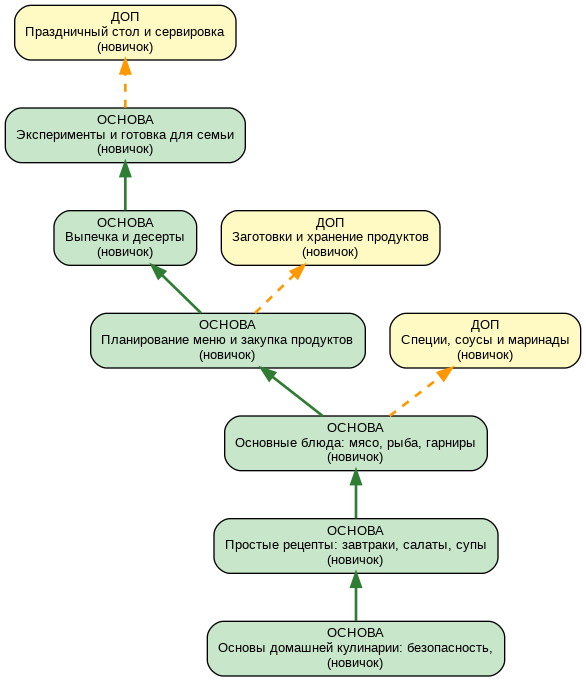


👉 ТВОЙ ШАГ 1 [ОСНОВА] Основы домашней кулинарии: безопасность, инструменты, базовые техники
💡 Зачем это нужно: Обязательный навык для продвижения вперед.
🎯 Навыки: безопасность на кухне, основные инструменты, базовые техники
🔗 Ссылка: https://www.youtube.com/results?search_query=%D0%9E%D1%81%D0%BD%D0%BE%D0%B2%D1%8B%20%D0%B4%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D0%B5%D0%B9%20%D0%BA%D1%83%D0%BB%D0%B8%D0%BD%D0%B0%D1%80%D0%B8%D0%B8%3A%20%D0%B1%D0%B5%D0%B7%D0%BE%D0%BF%D0%B0%D1%81%D0%BD%D0%BE%D1%81%D1%82%D1%8C%2C%20%D0%B8%D0%BD%D1%81%D1%82%D1%80%D1%83%D0%BC%D0%B5%D0%BD%D1%82%D1%8B%2C%20%D0%B1%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B5%20%D1%82%D0%B5%D1%85%D0%BD%D0%B8%D0%BA%D0%B8%20%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5
💡 Когда будешь готов перейти дальше — напиши 'дальше' или '/test'.

👤 Ты: дальше

🤖 Прогрессор: Для этого этапа в базе нет теста. Засчитываю автоматом! 🎉

👉 СЛЕДУЮЩИЙ ШАГ [ОСНОВА] Простые рецепты: завтраки, салаты, супы
💡 Зачем это нужно: Обязательный навык для продвижения вперед

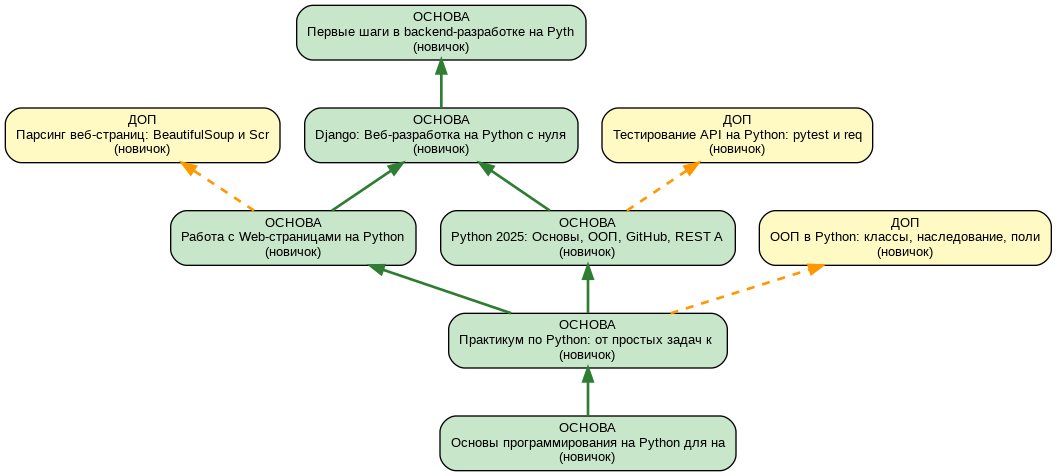


👉 ТВОЙ ШАГ 1 [ОСНОВА] Основы программирования на Python для начинающих
💡 Зачем это нужно: Структурированный курс по основам программирования на Python для начинающих — закрепляет базовые конструкции: переменные, типы данных, циклы, условия.
🎯 Навыки: python, основы_программирования
🔗 Ссылка: https://stepik.org/course/286790
💡 Когда будешь готов перейти дальше — напиши 'дальше' или '/test'.


In [ ]:
# =====================================================================
# БЛОК 8: БЕСКОНЕЧНЫЙ ЧАТ (АВТОПАСС ТЕСТОВ И ФИКС ДУБЛЕЙ)
# =====================================================================

import time
import sys
import random
import re
from typing import List, Dict, Optional

# (Оставляем функции _norm_text, _has_any_root, _extract_topic_from_phrase, _print_course_info, _graph_start_node, _nodes_by_id, класс UserSession без изменений)

def _norm_text(s: str) -> str:
    s = (s or "").lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

def _has_any_root(text: str, roots: List[str]) -> bool:
    t = _norm_text(text)
    return any(r in t for r in roots)

def _extract_topic_from_phrase(text: str) -> Optional[str]:
    t = _norm_text(text)
    patterns = [
        r"(?:новая тема|другая тема|хочу|давай|перейд[её]м на|сделай|построй)\s*[:\-]?\s*(.+)$",
        r"(?:тема)\s*[:\-]\s*(.+)$",
    ]
    for p in patterns:
        m = re.search(p, t)
        if m:
            cand = m.group(1).strip(" .,!?:;\"'")
            if len(cand) >= 3: return cand
    if 3 <= len(t) <= 40 and len(t.split()) <= 4: return t
    return None

def _print_course_info(course: Dict, prefix: str = "👉") -> None:
    if not course:
        return
    label = "ОСНОВА" if course.get("is_core") else "ДОП ВЕТКА"
    print(f"\n{prefix} [{label}] {course.get('title')}")
    why = course.get("why_useful") or "Этот этап нужен, чтобы двигаться дальше по треку."
    print(f"💡 Зачем это нужно: {why}")
    if course.get("skills"):
        skills = ", ".join(course["skills"][:6])
        print(f"🎯 Навыки: {skills}")
    print(f"🔗 Ссылка: {course.get('url')}")

def _graph_start_node(graph: Dict) -> Optional[str]:
    nodes = graph.get("nodes", []) if isinstance(graph.get("nodes"), list) else []
    core0 = None
    if isinstance(graph.get("core_path"), list) and graph["core_path"]:
        core0 = str(graph["core_path"][0])
    if core0:
        for n in nodes:
            if str(n.get("node_id")) == core0: return core0
    for n in nodes:
        if not n.get("dependencies"): return str(n.get("node_id"))
    return str(nodes[0].get("node_id")) if nodes else None

def _nodes_by_id(graph: Dict) -> Dict[str, Dict]:
    out = {}
    for n in graph.get("nodes", []) if isinstance(graph.get("nodes"), list) else []:
        if isinstance(n, dict) and n.get("node_id") is not None:
            out[str(n["node_id"])] = n
    return out

class UserSession:
    def __init__(self):
        self.state = "interview"
        self.profile: Dict = {}
        self.graph: Dict = {}
        self.completed_nodes: List[str] = []
        self.current_node_id: Optional[str] = None
        self.chat_history: List[Dict[str, str]] = []
        self.current_test_question: Optional[str] = None
        self.current_test_answer: Optional[str] = None
        self.available_choices: List[Dict] = []

    def get_current_course(self) -> Optional[Dict]:
        if not self.graph or not self.current_node_id: return None
        return _nodes_by_id(self.graph).get(str(self.current_node_id))

    def get_available_nodes(self) -> List[Dict]:
        if not self.graph: return []
        nodes = _nodes_by_id(self.graph)
        available = []
        completed = set(str(x) for x in self.completed_nodes)

        for node_id, node in nodes.items():
            if node_id in completed: continue
            deps = [str(d) for d in node.get("dependencies", [])]
            if all(d in completed for d in deps):
                available.append(node)
        available.sort(key=lambda n: (0 if n.get("is_core") else 1, str(n.get("node_id"))))
        return available

    def mark_current_complete(self):
        if self.current_node_id and str(self.current_node_id) not in self.completed_nodes:
            self.completed_nodes.append(str(self.current_node_id))

def _show_map(session: UserSession):
    if not session.graph or session.state == "interview":
        print("\n🤖 Прогрессор: Карта ещё не построена.")
        return
    print("\n🗺️ ТВОЙ ТЕКУЩИЙ ROADMAP:")
    if generate_graph_visualization(session.graph):
        display_graph_in_colab("/content/roadmap_graph.png")
        time.sleep(0.3)
    # УБРАЛИ ДУБЛЬ ИНФОРМАЦИИ ОТСЮДА!

def _start_learning_from_graph(session: UserSession) -> bool:
    start_id = _graph_start_node(session.graph)
    if not start_id:
        print("\n🤖 Прогрессор: Не получилось сгенерировать стартовый курс. Попробуй 'заново'.")
        return False

    session.current_node_id = str(start_id)
    session.state = "learning"
    export_state_for_miniapp(session.profile, session.graph, session.completed_nodes)

    print("\n" + "="*70)
    print("🗺️ ROADMAP УСПЕШНО СОЗДАН!")
    print("="*70)

    motivation = session.graph.get("roadmap_motivation")
    if motivation:
        print(f"\n🧠 Почему такой план: {motivation}")

    _show_map(session)
    curr = session.get_current_course()
    _print_course_info(curr, prefix="👉 ТВОЙ ШАГ 1")
    print("💡 Когда будешь готов перейти дальше — напиши 'дальше' или '/test'.")
    return True

def run_colab_chat():
    session = UserSession()

    print("\n" + "="*70)
    print("🤖 ПРОГРЕССОР: Привет! Чему бы ты хотел научиться?")
    print("Команды: 'карта', 'перестрой', 'заново', '/test' или 'дальше', 'выход'")
    print("="*70)

    ROOT_EXIT = ["выход", "exit", "quit", "q"]
    ROOT_SHOW_MAP = ["карта", "граф", "роадмап", "roadmap", "map", "покажи текущий"]
    ROOT_RESET = ["заново", "сброс", "новая тема", "другая тема", "хочу другое", "другому", "перейти на другую", "начни сначала"]
    ROOT_REBUILD = ["перестро", "передел", "измен", "поменя", "скоррект", "обнови план"]
    ROOT_ADVANCE = ["/test", "тест", "дальше", "вперед", "next", "готово", "завершил", "прошел", "законч"]
    ROOT_BACK = ["назад", "отмена", "cancel", "back", "пропустить"]

    while True:
        try:
            time.sleep(0.1)
            sys.stdout.flush()
            user_input = input("\n👤 Ты: ").strip()
            if not user_input: continue
            txt = _norm_text(user_input)

            if txt in ROOT_EXIT:
                print("\n👋 Пока! Удачи в обучении.")
                break

            if _has_any_root(txt, ROOT_SHOW_MAP):
                _show_map(session)
                curr = session.get_current_course()
                if curr:
                    _print_course_info(curr, prefix="📍 Ты сейчас на этапе")
                continue

            if _has_any_root(txt, ROOT_RESET):
                print("\n🤖 Прогрессор: Ок, начинаем заново. Чему хочешь научиться?")
                session = UserSession()
                continue

            if _has_any_root(txt, ROOT_REBUILD) and session.state in ["learning", "testing", "choosing"]:
                print("\n🤖 Прогрессор: Что именно изменить? (например: 'добавь практику', 'сделай быстрее')")
                session.state = "rebuild"
                continue

            if session.state == "testing" and _has_any_root(txt, ROOT_BACK):
                session.state = "learning"
                curr = session.get_current_course()
                print("\n🤖 Прогрессор: Ок, вернулись к этапу.")
                _print_course_info(curr, prefix="📍 Текущий этап")
                continue

            # --- ИНТЕРВЬЮ ---
            if session.state == "interview":
                session.chat_history.append({"role": "user", "content": user_input})
                if len(session.chat_history) > 8: session.chat_history = session.chat_history[-8:]
                res = run_interview_chat_step(session.chat_history)

                if res.get("status") == "blocked":
                    print(f"\n🛑 Прогрессор: {res.get('message')}")
                    session.chat_history = []
                    continue

                if res.get("status") == "need_more":
                    msg = res.get("message", "Уточни, пожалуйста.")
                    session.chat_history.append({"role": "assistant", "content": msg})
                    print(f"\n🤖 Прогрессор: {msg}")
                    continue

                if res.get("status") == "ready":
                    session.profile = res.get("profile", {})
                    print(f"\n🤖 Прогрессор: {res.get('message', 'Собираю план...')}")
                    print("⚙️ (Системно: Подбираю курсы и строю граф...)")

                    session.graph = build_complete_roadmap(session.profile)
                    if not session.graph or not session.graph.get("nodes"):
                        print("\n🤖 Прогрессор: Не смог построить план. Попробуй уточнить тему.")
                        session = UserSession()
                        continue

                    if not _start_learning_from_graph(session):
                        session = UserSession()
                    continue

            # --- ОБУЧЕНИЕ ---
            elif session.state == "learning":
                if _has_any_root(txt, ROOT_ADVANCE):
                    curr = session.get_current_course()
                    if not curr: continue
                    course_id = str(curr.get("course_id", ""))
                    tests = tests_db.get(course_id, [])

                    if tests:
                        t = random.choice(tests)
                        q = t.get("question") or t.get("q")
                        a = t.get("correct_answer") or t.get("answer") or t.get("a")
                        if q and a:
                            session.current_test_question = str(q)
                            session.current_test_answer = str(a)
                            session.state = "testing"
                            print(f"\n🤖 Прогрессор: Проверяем знания! Вопрос:\n❓ {session.current_test_question}")
                            print("💡 Можно написать 'назад', чтобы вернуться к курсу.")
                            continue

                    # ОТКЛЮЧЕНО ПРИДУМЫВАНИЕ ТЕСТОВ - СРАЗУ АВТО-ПАСС
                    print("\n🤖 Прогрессор: Для этого этапа в базе нет теста. Засчитываю автоматом! 🎉")
                    session.mark_current_complete()
                    export_state_for_miniapp(session.profile, session.graph, session.completed_nodes)

                    available = session.get_available_nodes()

                    if not available:
                        print("\n🏁 Ты прошёл весь роадмап! Если хочешь новую тему — напиши 'заново'.")
                        session.current_node_id = None
                        continue

                    if len(available) == 1:
                        session.current_node_id = str(available[0].get("node_id"))
                        nxt = session.get_current_course()
                        _print_course_info(nxt, prefix="👉 СЛЕДУЮЩИЙ ШАГ")
                        print("💡 Когда будешь готов — 'дальше' или '/test'.")
                        continue

                    # ВЕТВЛЕНИЕ
                    session.state = "choosing"
                    session.available_choices = available
                    print("\n🤖 Прогрессор: Открыто несколько путей — выбери номер:")
                    for idx, node in enumerate(available, 1):
                        label = "📍 ОСНОВА" if node.get("is_core") else "🌿 ДОП"
                        print(f"  {idx}. [{label}] {node.get('title')}")
                    continue

                session.chat_history.append({"role": "user", "content": user_input})
                if len(session.chat_history) > 8: session.chat_history = session.chat_history[-8:]
                curr = session.get_current_course()
                reply = chat_with_mentor(session.chat_history, (curr or {}).get("title", ""))
                session.chat_history.append({"role": "assistant", "content": reply})
                print(f"\n🤖 Прогрессор: {reply}")
                continue

            # --- ТЕСТИРОВАНИЕ ---
            elif session.state == "testing":
                q = session.current_test_question or ""
                a = session.current_test_answer or ""
                print("⚙️ (Оцениваю твой ответ...)")
                verdict = evaluate_test_answer(q, a, user_input)

                if verdict.get("passed"):
                    print(f"\n🤖 Прогрессор: ✅ Засчитано! {verdict.get('feedback', '')}".strip())
                    session.mark_current_complete()
                    export_state_for_miniapp(session.profile, session.graph, session.completed_nodes)

                    available = session.get_available_nodes()
                    session.state = "learning"

                    if not available:
                        print("\n🏁 Ты прошёл весь роадмап! Если хочешь новую тему — напиши 'заново'.")
                        session.current_node_id = None
                        continue

                    if len(available) == 1:
                        session.current_node_id = str(available[0].get("node_id"))
                        nxt = session.get_current_course()
                        _print_course_info(nxt, prefix="👉 СЛЕДУЮЩИЙ ШАГ")
                        print("💡 Когда будешь готов — 'дальше' или '/test'.")
                        continue

                    session.state = "choosing"
                    session.available_choices = available
                    print("\n🤖 Прогрессор: Открыто несколько путей — выбери номер:")
                    for idx, node in enumerate(available, 1):
                        label = "📍 ОСНОВА" if node.get("is_core") else "🌿 ДОП"
                        print(f"  {idx}. [{label}] {node.get('title')}")
                    continue

                print(f"\n🤖 Прогрессор: ❌ Не засчитано. {verdict.get('feedback', '')}".strip())
                print("Попробуй ещё раз или напиши 'назад' чтобы вернуться к курсу.")
                continue

            # --- ВЫБОР ---
            elif session.state == "choosing":
                try:
                    idx = int(txt) - 1
                    if 0 <= idx < len(session.available_choices):
                        chosen = session.available_choices[idx]
                        session.current_node_id = str(chosen.get("node_id"))
                        session.state = "learning"
                        _print_course_info(session.get_current_course(), prefix="👉 ТЫ ВЫБРАЛ")
                        print("💡 Когда будешь готов — 'дальше' или '/test'.")
                    else:
                        print("🤖 Прогрессор: Введи корректный номер из списка.")
                except ValueError:
                    print("🤖 Прогрессор: Напиши цифру (например: 1).")
                continue

            # --- ПЕРЕСТРОЙКА ---
            elif session.state == "rebuild":
                maybe_topic = _extract_topic_from_phrase(user_input)
                if maybe_topic: session.profile["target_topic"] = maybe_topic
                session.profile["goal"] = (session.profile.get("goal") or "") + f". УТОЧНЕНИЕ: {user_input}"

                print("\n⚙️ (Системно: Пересобираю роадмап с учётом твоего запроса...)")
                session.graph = build_complete_roadmap(session.profile)
                session.completed_nodes = []

                if not _start_learning_from_graph(session):
                    session = UserSession()
                continue

        except KeyboardInterrupt:
            print("\nОстановка чата.")
            break

if __name__ == "__main__":
    run_colab_chat()